In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib


In [ ]:
df = pd.read_csv('../reference/employee_salary_regression.csv')
X = df.drop(columns=['employee_id', 'annual_salary_usd'])
y = df['annual_salary_usd']
df.dtypes

employee_id              str
age                    int64
years_experience       int64
education_level          str
job_role                 str
city_tier              int64
performance_score    float64
num_skills             int64
remote_work            int64
annual_salary_usd    float64
dtype: object

In [8]:
df.education_level.value_counts()

education_level
Bachelor       258
PhD            256
Master         246
High School    240
Name: count, dtype: int64

In [20]:
# pisahkan feature numeric dan categoric (ordinal (pakai ordinal encoder), dan nominal (pakai onehot encoder))
from statistics import median


numeric_features = ['age', 'years_experience', 'city_tier', 'performance_score', 'num_skills', 'remote_work']
categoric_ordinal = ['education_level']
categoric_nominal = ['job_role']

# isi dari categoric ordinal
edu_cats =[['High School', 'Bachelor', 'Master', 'PhD']]

# preprocessing 
# pipe 1 (scaling numeric features)
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

# pipe 2 (encode ordinal dan scaling)
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=edu_cats)),
    ('scaler', StandardScaler())])

# pipe 3 (onehot encode cat_nominal)
nominal_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features ),
    ('ord', ordinal_transformer, categoric_ordinal),
    ('nom', nominal_transformer, categoric_nominal )
])

# pipe 4 full column transformer, feature selection, dan models 
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_regression, k= 'all')),
    ('regressor', Ridge(alpha=1.0))
])

# splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train 
pipe_lr.fit(X_train, y_train)
y_pred= pipe_lr.predict(X_test)

# eval
def eval(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"--- Evaluasi {name} ---")
    print(f"R-squared (R2) : {r2:.4f}")
    print(f"RMSE           : {rmse:.2f}")
    print(f"MAE            : {mae:.2f}\n")

eval(pipe_lr, 'Ridge Regression', X_test, y_test)

--- Evaluasi Ridge Regression ---
R-squared (R2) : 0.9851
RMSE           : 4426.90
MAE            : 3567.65



''

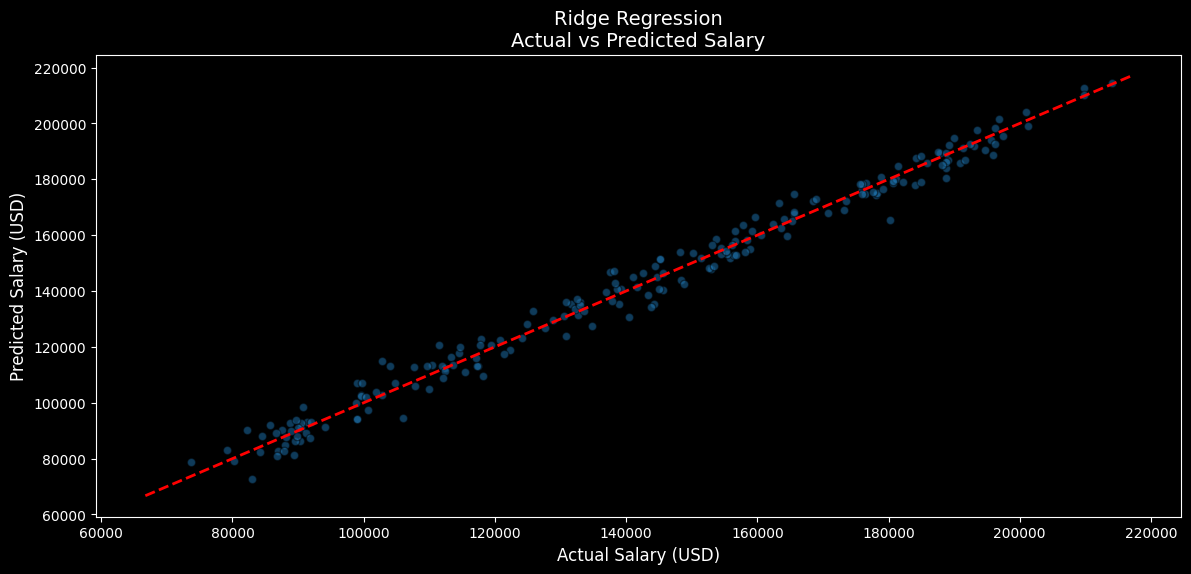

In [29]:
# ploting

plt.figure(figsize=(14, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='#1f77b4', edgecolor='k')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Ridge Regression\nActual vs Predicted Salary', fontsize=14)
plt.xlabel('Actual Salary (USD)', fontsize=12)
plt.ylabel('Predicted Salary (USD)', fontsize=12)
;


In [14]:
joblib.dump(pipe_lr, 'lr_salary_model.pkl')

['lr_salary_model.pkl']